# This library was used to explore the application of DeepLIFT/SHAP

As DeepLIFT does not work well with residual networks, I looked at DeepSHAP python implementations. The two common libraries are SHAP and Captum, which gave me issues related to high convergence deltas. I found a newer library called Tangermeme, which builds off of Captums implementation but is significantly better documented. I left the code I used when trying SHAP and Captum, but the Tangermeme is what produced consistent results. I recommend going with the Tangermeme implemention going forward for this task. 

In [2]:
import numpy as np
import sys
import time
import h5py
from tqdm import tqdm

import numpy as np
import re
from math import ceil
from sklearn.metrics import average_precision_score
from torch.utils.data import Dataset
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import pickle
#import pickle5 as pickle
import os
from sklearn.model_selection import train_test_split

from scipy.sparse import load_npz
from glob import glob

from transformers import get_constant_schedule_with_warmup
from sklearn.metrics import precision_score,recall_score,accuracy_score

from src.train import trainModel
from src.dataloader import getData,spliceDataset,h5pyDataset,collate_fn, getDataPointListFull
from src.weight_init import keras_init
from src.losses import categorical_crossentropy_2d
from src.model_shap import SpliceFormer, SpliceAI_10K
from src.evaluation_metrics import print_topl_statistics
import copy
from collections import defaultdict
from collections import OrderedDict
import shap
from pytorch_grad_cam import GradCAM
from tangermeme.deep_lift_shap import deep_lift_shap
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute
from tangermeme.ersatz import dinucleotide_shuffle
from tangermeme.plot import plot_logo

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading entire test dataset, and looking at the CFTR gene specifically. Other transcripts can be investigated as well, however if they are not in the test set then they cannot be accesssed as easily as is done in the variable 'specific_anno' (just specifying the name 'CFTR'). To select specific transcripts for testing outside of train/test set, the procedure depends on the transcript length. SpliceAI-10k and Transformer-40k take 15,000 and 45,000 input sequences, respectively. If the transcript of interest is shorter than this length, zero padding must be added on either side of the transcript to satisfy the respective input. This can be done with the following functions, 'pad_sequence' and 'one_hot_encode'.

In [6]:
data_dir = '../Data'
setType = 'test'
annotation_test, transcriptToLabel_test, seqData = getData(data_dir, setType)
specific_anno = annotation_test[annotation_test['name'].apply(lambda x: x.split('--')[0])=='CFTR']


                                                   name chrom strand  \
7438  CFTR---ENSG00000001626.14---ENST00000003084.10...  chr7      +   

       tx_start     tx_end       transcript             gene  
7438  117479963  117668665  ENST00000003084  ENSG00000001626  


In [4]:
# Function used to pad sequence with 'N' to satisfy the 45,000 input
def pad_sequence(sequence, target_length):
    # Calculate the total padding required
    total_padding = target_length - len(sequence)

    # Calculate padding for each side
    left_padding = total_padding // 2
    right_padding = total_padding - left_padding

    # Pad the sequence
    padded_sequence = 'N' * left_padding + sequence + 'N' * right_padding

    return padded_sequence, left_padding, right_padding

In [5]:
# Function used to perform one_hot_encoding
def one_hot_encode(sequence):
    # Define the encoding map
    encoding_map = {
        'A': [1, 0, 0, 0],
        'C': [0, 1, 0, 0],
        'G': [0, 0, 1, 0],
        'T': [0, 0, 0, 1],
        'N': [0, 0, 0, 0]
    }

    # Initialize an array to hold the one-hot encoded sequence
    one_hot_array = np.zeros((len(sequence), 4), dtype=int)

    # Populate the one-hot encoded array
    for i, nucleotide in enumerate(sequence):
        one_hot_array[i] = encoding_map.get(nucleotide, [0, 0, 0, 0])

    return one_hot_array

Note that I only looked at DeepSHAP results for the SpliceAI model. In principle DeepSHAP should me model agnostic so it should be able to run with Transformer-40k, but as Transformer-40k is more complex getting DeepSHAP to run correctly may take some rewriting of certain non-linear layers in the model code. I was going to look into getting DeepSHAP to run with Transformer-40k but so far only implemented it for SpliceAI. 

In [10]:
# Code to load spliceai model

CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            name = k[7:] # remove `module.`
            new_state_dict[name] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

Due to the issues implementing DeepSHAP, one suggestion online that I tried was defining each 'skip_layer_i' and 'res_layer_i' in the SpliceAI_10K model separately, as opposed to using list comprehension with nn.ModuleList. So the original model code has:

self.skip_layers = nn.ModuleList([nn.Conv1d(in_channels=n_channels, out_channels=n_channels, kernel_size= self.kernel_size,stride=1) for i in range(5)])
self.res_layers = nn.ModuleList([ResComboBlock(in_channels=n_channels, out_channels=n_channels, res_W=self.res_W[i], res_dilation=res_dilation[i]) for i in rang(4)])

Whereas I tried writing out each layer as self.skip_layer_1, self.skip_layer_2,... etc.

Since DeepLIFT/SHAP is so sensitive to how layers are defined in Pytorch, I wasn't sure if it was equipped to handle nn.ModuleList. But this didn't solve the issue at the time so I switched the model code back to using nn.ModuleList. But the following code was used to load the model without nn.ModuleList, as removing nn.ModuleList changed the keys. This can be ignored as the model is back to having nn.ModuleList

In [3]:
CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K(CL_max)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]

if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            new_key = k[7:] # remove `module.`
            # print(name)
        # Handle skip_layers.N → skip_layers_(N+1)
            if k[7:].startswith("skip_layers."):
                parts = k[7:].split(".", 2)  # ["skip_layers", "0", "weight"]
                idx, rest = parts[1], parts[2]
                new_key = f"skip_layers_{int(idx)+1}.{rest}"

        # Handle res_layers.N → res_layers_(N+1)
            elif k[7:].startswith("res_layers."):
                parts = k[7:].split(".", 2)  # ["res_layers", "0", "comboBlock..."]
                idx, rest = parts[1], parts[2]
                new_key = f"res_layers_{int(idx)+1}.{rest}"

            new_state_dict[new_key] = v

        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

RuntimeError: Error(s) in loading state_dict for SpliceAI_10K:
	Missing key(s) in state_dict: "skip_layers.0.weight", "skip_layers.0.bias", "skip_layers.1.weight", "skip_layers.1.bias", "skip_layers.2.weight", "skip_layers.2.bias", "skip_layers.3.weight", "skip_layers.3.bias", "skip_layers.4.weight", "skip_layers.4.bias", "res_layers.0.comboBlock.0.convlayer1.weight", "res_layers.0.comboBlock.0.convlayer1.bias", "res_layers.0.comboBlock.0.convlayer2.weight", "res_layers.0.comboBlock.0.convlayer2.bias", "res_layers.0.comboBlock.0.bn1.weight", "res_layers.0.comboBlock.0.bn1.bias", "res_layers.0.comboBlock.0.bn1.running_mean", "res_layers.0.comboBlock.0.bn1.running_var", "res_layers.0.comboBlock.0.bn2.weight", "res_layers.0.comboBlock.0.bn2.bias", "res_layers.0.comboBlock.0.bn2.running_mean", "res_layers.0.comboBlock.0.bn2.running_var", "res_layers.0.comboBlock.1.convlayer1.weight", "res_layers.0.comboBlock.1.convlayer1.bias", "res_layers.0.comboBlock.1.convlayer2.weight", "res_layers.0.c

DeepSHAP requires a specific output prediction, so this class was used to specify a specific prediction for the model using 'target_idx'

In [7]:
class WrappedModel(nn.Module):
    def __init__(self, base_model, target_idx):
        super().__init__()
        self.base_model = base_model
        self.target_idx = target_idx

    def forward(self, x):
        out = self.base_model(x)
        scalar = out[:, self.target_idx[0], self.target_idx[1]] # OR out[0][:, self.target_idx[0], self.target_idx[1]] if using Transformer-40k
        return scalar.unsqueeze(1) # shape batch_size,n_targets

### Captum and SHAP trial implementations (can skip and go to Tangermeme implementation)

In [9]:
# In general, it's recommended to use a subset of your training data as the background or reference for DeepSHAP. 
# However, I later switched to using a di-nucleotide shuffle of my input sequence as the reference
SL = 5000
CL_max = 10000
BATCH_SIZE = 100

test_dataset = spliceDataset(getDataPointListFull(annotation_test,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
batch, _ = next(iter(test_loader))
background = batch.type(torch.FloatTensor).to(device) # 100 samples
print(background.shape)

/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


NameError: name 'device' is not defined

In [11]:
# Loading a specific slice of the CFTR transcript used to testing. Since both SpliceAI_10K and Transformer-40K make predictions on a middle 5,000 nucleotide region,
# the entire transcript is loaded in a sliding 5,000 region. So as CFTR is ~188k nt, performing predictions with a middle 5,000 region requires 38 different steps,
# as 38*5000 = 190k
# For testing purposes I am simply loading the fourth iteration of this, centered at 20k nt into the transcript
specific_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
specific_dataset.seqData = seqData
specific_loader = torch.utils.data.DataLoader(specific_dataset, batch_size=38, shuffle=False, num_workers=0, pin_memory=True)
specific_results, specific_target = next(iter(specific_loader))
specific_results = specific_results.type(torch.FloatTensor).to('cpu')
specific_results = torch.unsqueeze(specific_results[4],dim=0)
print(specific_results.shape)
print('Acceptor',np.where(specific_target[4,1,:]==1))
print('Donor',np.where(specific_target[4,2,:]==1))


torch.Size([1, 4, 15000])
Acceptor (array([ 9290, 14071]),)
Donor (array([ 9400, 14179]),)


SHAP library implementation

In [12]:
explainer = []
X_ref = dinucleotide_shuffle(specific_results,n=20,random_state=0) # Using dinucleotide_shuffle from Tangermeme library
for model in models:
    wrapped_model = WrappedModel(model, target_idx=(1, 4290)) # 
    e = shap.DeepExplainer(wrapped_model,X_ref[0])
    break # SpliceAI_10k and Transformer-40k have ten saved models where the average across the ten models is taken. For testing purposes I only looked at one of these ten models

In [13]:
shap_value = e.shap_values(specific_results,check_additivity=False) 

(1, 4, 15000)
13.793017638161823


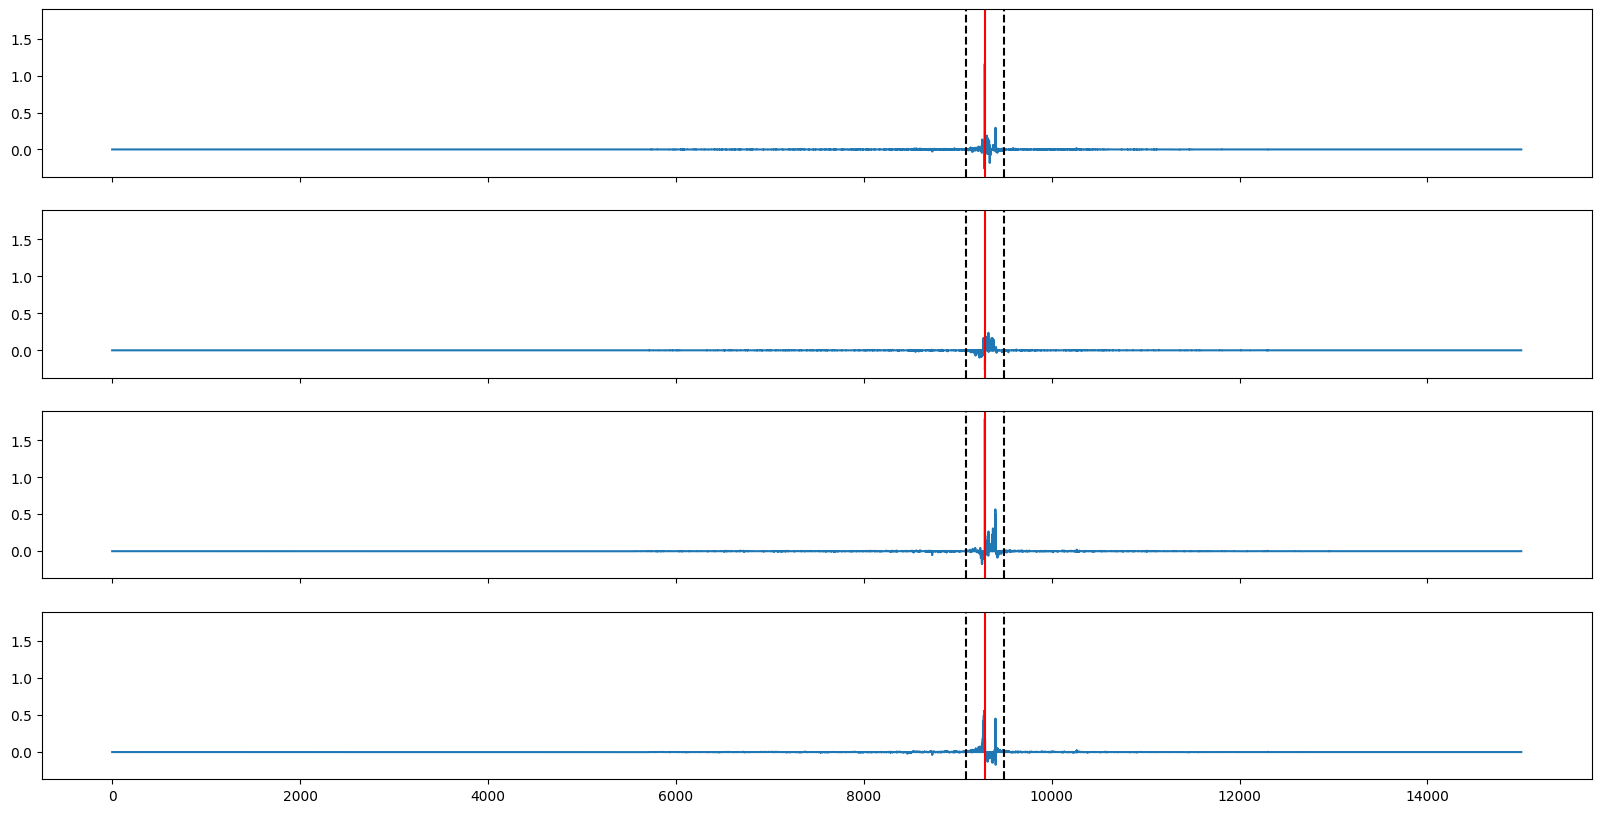

In [40]:
# Quick plot of results from shap.DeepExplainer
b = np.sum(shap_value[0,:,:,0])
shap_shap = shap_value[:,:,:,0]  * specific_results.detach().numpy() # Multiply by one-hot encoding sequence as only one nucleotide can be present at each location
# shap_shap = shap_value[:,:,:,0]
print(shap_shap.shape)
print(np.sum(shap_shap[0,:,:]))

fig, axs = plt.subplots(4, figsize=(20,10),sharex=True, sharey=True)
for i in range(4):
    # shap_shap[0,i,:] /= np.max(shap_shap[0,i,:])
    axs[i].plot(shap_shap[0,i,:])
    # axs[i].set_xlim(9290-200,9290+200)
    axs[i].axvline(9290,color='red')
    axs[i].axvline(9290+200,color='black',linestyle='--')    
    axs[i].axvline(9290-200,color='black',linestyle='--')

plt.show()
plt.close()

# fig = plt.figure(figsize=(22,22))
# plt.plot(shap_shap[0,0,:]+shap_shap[0,3,:],label=f'T + A')
# plt.plot(shap_shap[0,1,:]+shap_shap[0,2,:],label=f'G + C')

# plt.xlim(9290-200,9290+200)
# plt.legend()
# plt.show()
# plt.close()

Captum implementation

In [18]:
from captum.attr import DeepLiftShap
X_ref = dinucleotide_shuffle(specific_results,n=20,random_state=0)
for model in models:
    dl = DeepLiftShap(model) 
    attribution = dl.attribute(specific_results,X_ref[0],target=(1,4290),return_convergence_delta=True)
    break

(1, 4, 15000)
[13.793017]


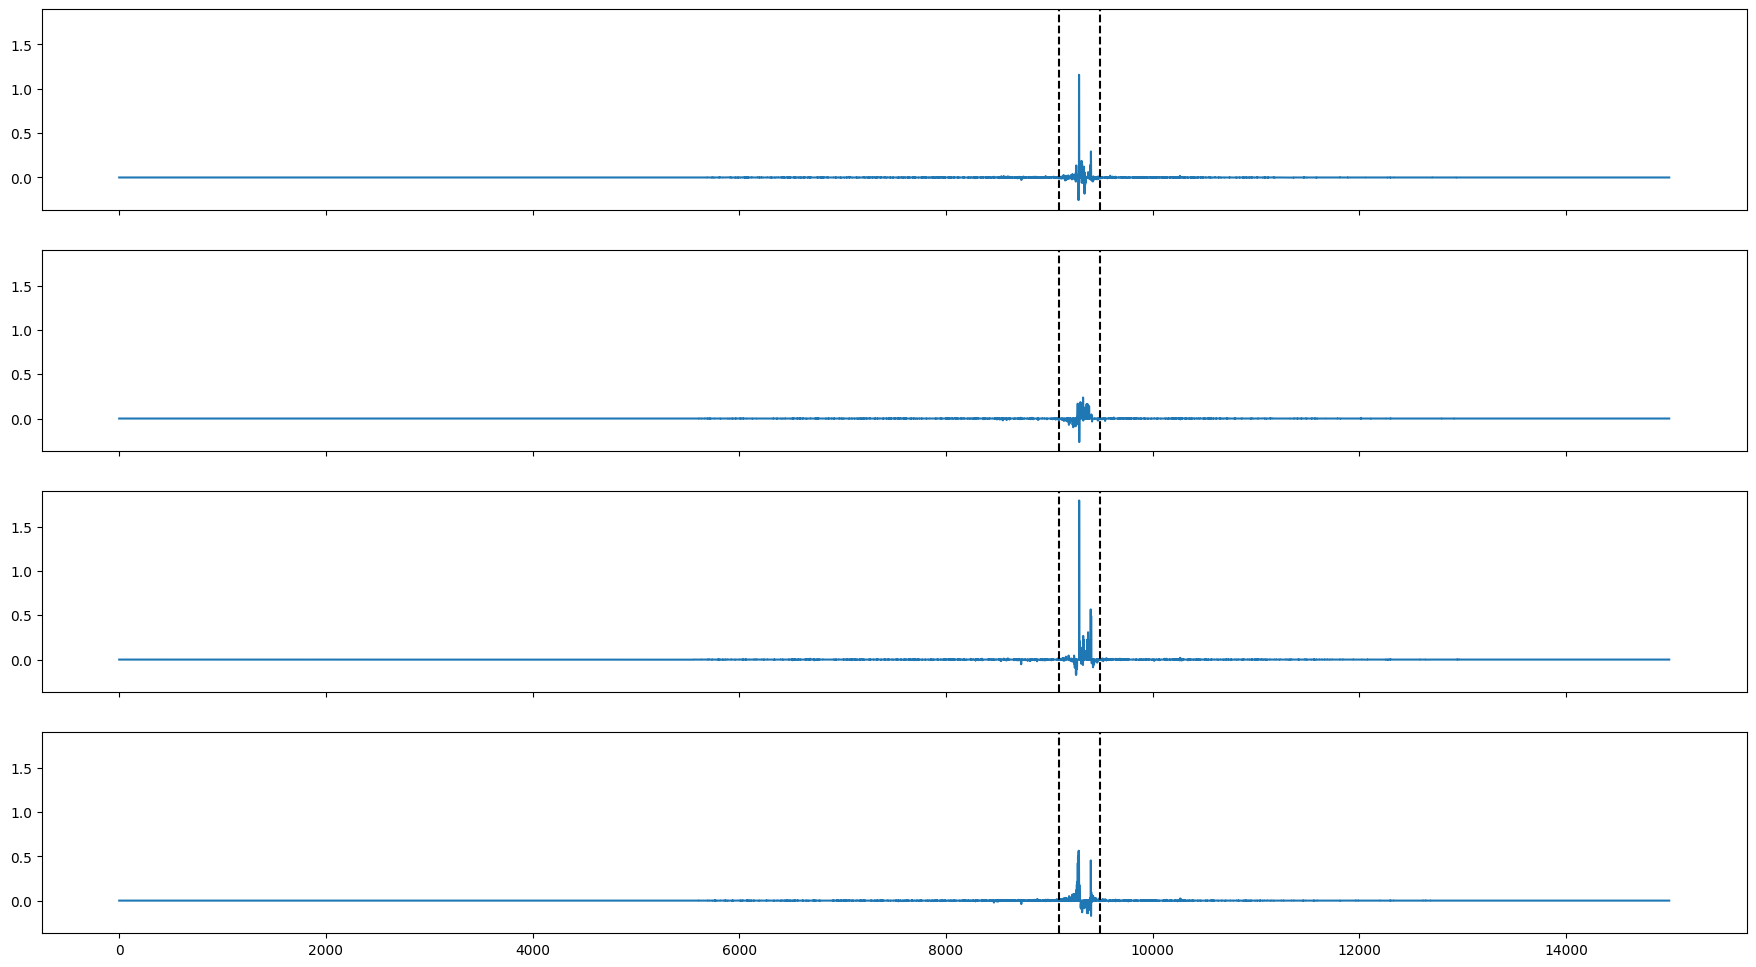

In [39]:
captum_shap = attribution[0].detach().numpy() * specific_results.detach().numpy() # Multiply by one-hot encoding sequence as only one nucleotide can be present at each location
print(captum_shap.shape)
print(np.sum(captum_shap, axis=(1,2)))

fig, axs = plt.subplots(4, figsize=(22,12),sharex=True, sharey=True)
for i in range(4):
    # captum_shap[0,i,:] /= np.max(captum_shap[0,i,:])
    axs[i].plot(captum_shap[0,i,:])
    # axs[i].set_xlim(9290-210,9290+210)
    # axs[i].axvline(9290,color='red')
    axs[i].axvline(9290+200,color='black',linestyle='--')    
    axs[i].axvline(9290-200,color='black',linestyle='--')

plt.show()
plt.close()

# Testing tangermeme implementation


Another thing I tried when DeepSHAP would not run correctly was re-writing SpliceAI_10k in a single class, as opposed to how it originally was written, with ResComboBlock and ResidualBlock being defined as separate classes. This didn't solve the issue, so I switched back to the using the original SpliceAI_10k how it was written. Having the model defined as a single class changed the keys, so this code was just used to correct the keys when loading the model. Can be ignored.

In [22]:
CL_max=10000
SL=5000

NUM_ACCUMULATION_STEPS = 1
temp = 1
n_models = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m = SpliceAI_10K_FullInit(CL_max,crop=False)
model_m.apply(keras_init)
model_m = model_m.to(device)

if torch.cuda.device_count() > 1:
    model_m = nn.DataParallel(model_m)

output_class_labels = ['Null', 'Acceptor', 'Donor']

#for output_class in [1,2]:
models = [copy.deepcopy(model_m) for i in range(n_models)]
new_state_dict = []
if torch.cuda.device_count() > 1:
    [model.load_state_dict(torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i))) for i,model in enumerate(models)]
else:
    for i,model in enumerate(models):
        state_dict = torch.load('../Results/PyTorch_Models/spliceai_encoder_10k_191022_{}'.format(i), map_location=device)
        new_state_dict = OrderedDict()
        for k, v in state_dict.items():
            parts = k.split(".")[1:]
            if parts[0] == "res_layers":
  
                new_key = ".".join([parts[0], parts[1]] + parts[3:])
            else:
                new_key = k[7:]  # leave other keys untouched
            new_state_dict[new_key] = v
        model.load_state_dict(new_state_dict)

for model in models:
    model.eval()

Testing Tangermeme on single part of transcript. Convergence deltas finally look good after removing final softmax activation layer in SpliceAI_10k.

In [41]:
test = random_one_hot((1,4,15000),random_state=0).type(torch.float32)
X_ref = dinucleotide_shuffle(specific_results,n=20,random_state=0)
# _nonlinear = lambda x, grad_input, grad_output: grad_input
# additional_nonlinear_ops = {torch.nn.ReLU: _nonlinear}

for model in models:
    wrapped_model = WrappedModel(model, target_idx=(1, 4290))
    # y, y_ref = wrapped_model(specific_results), wrapped_model(X_ref[0])
    X_attr = deep_lift_shap(model=wrapped_model,X=specific_results,device='cpu',random_state=0,print_convergence_deltas=True)
    output = wrapped_model(specific_results)
    break

# output_diff = (y-y_ref)[:,0]
# input_diff = (specific_results - X_ref[0])
# convergence_t = abs(output_diff - torch.sum(input_diff * X_attr[0], dim=(1, 2))).numpy(force=True)
# print(convergence_t)

tensor([3.8147e-06, 3.8147e-06, 1.9073e-06, 5.7220e-06, 3.8147e-06, 1.9073e-06,
        3.8147e-06, 0.0000e+00, 1.9073e-06, 1.9073e-06, 5.7220e-06, 0.0000e+00,
        3.8147e-06, 1.9073e-06, 0.0000e+00, 1.9073e-06, 3.8147e-06, 1.9073e-06,
        0.0000e+00, 1.9073e-06], grad_fn=<AbsBackward0>)


Plotting the Tangermeme results. Tangermeme also has a built in function 'plot_logo', which comes from logo_maker in Python. This is another advantage of using Tangermeme as it has certain functionalities useful in a genomics context

24290


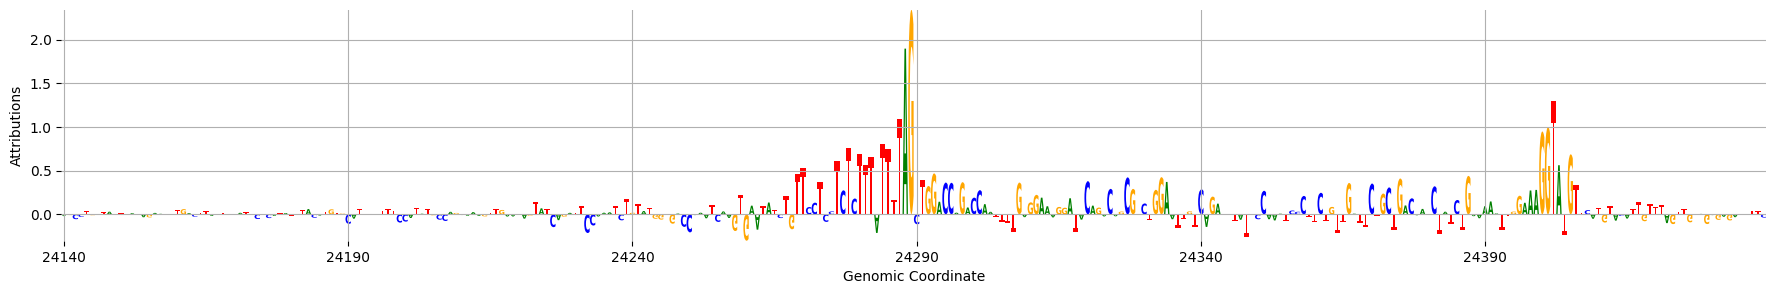

In [42]:
from tangermeme.plot import plot_logo
from matplotlib.transforms import Affine2D

plt.figure(figsize=(22, 3))
ax = plt.subplot(111)

plot_logo(X_attr[0, :, 9290-150:9290+150], ax=ax)


# start,end = 9290-150, 9290+150
# x_window = list(range(0+20000-5000,15000+20000-5000)[9290-150:9290+150])
# L = 300
# step = 50  # pick what you like (e.g., 25, 50, 100)
# tick_pos = np.arange(0, L, step, dtype=int)
# tick_lbl = [x_window[i] for i in tick_pos]
# ax.set_xticks(tick_pos)
# ax.set_xticklabels(tick_lbl)
# ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

x_window = np.arange(24140, 24440)
step = 50
tick_pos_local = np.arange(0, x_window.shape[-1], step)
tick_labels = [x_window[i] for i in tick_pos_local]
ax.set_xticks(tick_pos_local)
ax.set_xticklabels(tick_labels)
ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)
print(x_window[0]+150)
# abs_coord = 24291
# local_idx = np.where(x_window == abs_coord)[0][0]
# print(local_idx)
# ax.scatter(local_idx, 10, c='red', marker="^", clip_on=False, label='Annotated\nAcceptor',zorder=10)

# new_window = np.arange(24140,24440)
# ax.scatter(np.where(new_window == 24290)[0][0],0.1,c='red',marker="^", clip_on=False,label='Annotated\nAcceptor')

plt.grid()
plt.xlabel("Genomic Coordinate")
plt.ylabel("Attributions")


# ymin, ymax = ax.get_ylim()
# y = ymin - 0.01

# # extend plot so we can see gene schematic
# ax.set_ylim(y-0.01, ymax)
# # full horizontal line (gene backbone)
# # ax.axhline(y, color='k', linewidth=1)

# xs = np.arange(-3, len(X_attr[0, :, 9290-150:9290+150]), 10)   # or slice range length instead of shape[2]
# ys = y * np.ones(len(xs))
# ax.plot(xs, ys, marker='>', linewidth=0, markersize=7, color='k')

# # define an "exon" region (thick bar)
# exon_start = 120
# exon_stop = 180
# ax.plot([exon_start, exon_stop], [y, y], color='k', linewidth=5, solid_capstyle='butt')

# # annotate exon start with a triangle
# ax.plot(exon_start, y*1.8, '^k', markersize=12)

# ax.text(exon_start, y, "chr3:142,740,192", fontsize=10, ha='center', va='top')


plt.show()
plt.close()

Results look good, also want to see what it looks like decomposing the nucleotides

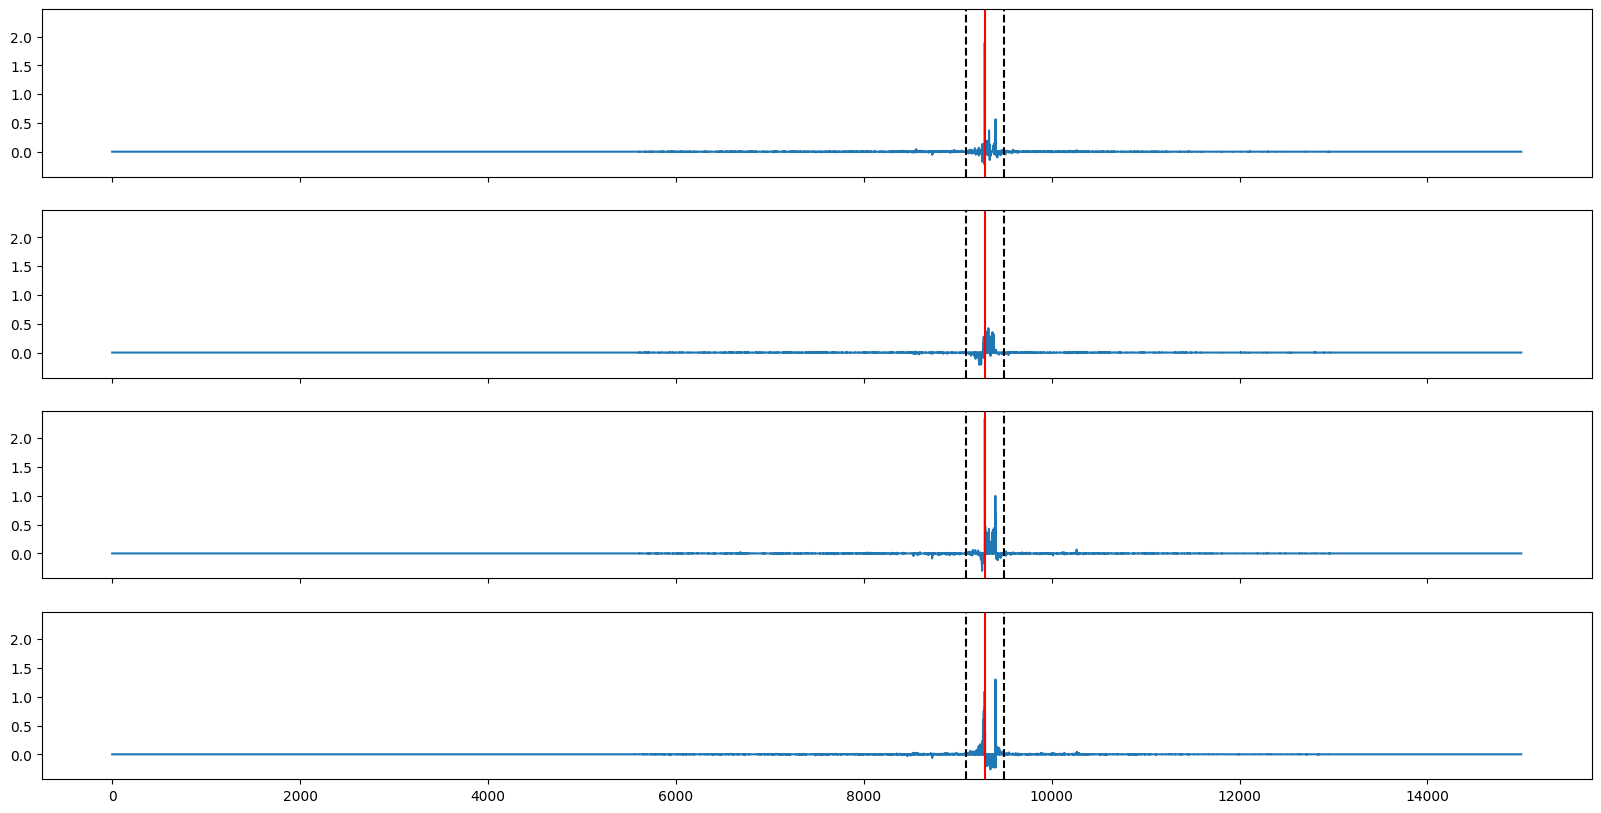

In [43]:
fig, axs = plt.subplots(4, figsize=(20,10),sharex=True, sharey=True)
for i in range(4):
    # shap_shap[0,i,:] /= np.max(shap_shap[0,i,:])
    axs[i].plot(X_attr[0,i,:])
    # axs[i].set_xlim(9290-100,9290+100)
    axs[i].axvline(9290,color='red')

    axs[i].axvline(9290+200,color='black',linestyle='--')    
    axs[i].axvline(9290-200,color='black',linestyle='--')

plt.show()
plt.close()

Now that DeepSHAP is running for a single case lets package this in some functions to make it easier to look at multiple transcripts

### DeepSHAP implementation

In [44]:
from collections import defaultdict
def deepshap_attr(model,batch_features,label,idx,start_shift,shift):
    start,end = 0,15000
    attributeDict = defaultdict(list)
    wrapped_model = WrappedModel(model, target_idx=(label+1, idx))
    X_attr = deep_lift_shap(model=wrapped_model,X=batch_features,device='cpu',random_state=0,print_convergence_deltas=True)
    plt.figure(figsize=(22, 3))
    ax = plt.subplot(111)
    seq_idx = idx+5000
    plot_logo(X_attr[0, :, seq_idx-150:seq_idx+150], ax=ax)

    x_window = np.arange(start+shift-start_shift,end+shift-start_shift)[seq_idx-150:seq_idx+150]
    step = 50
    tick_pos_local = np.arange(0, x_window.shape[-1], step)
    tick_labels = [x_window[i] for i in tick_pos_local]
    ax.set_xticks(tick_pos_local)
    ax.set_xticklabels(tick_labels)
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

    if label == 0:
        site = "Acceptor"
    elif label == 1:
        site = "Donor"
    else:
        site = "Unknown"

    plt.title(f"CFTR Gene {site} {x_window[0] + 150}")


    plt.grid()
    plt.xlabel("Distance from transcript start (nt)")
    plt.ylabel("Attributions")
    # plt.savefig(f'../Results/DeepSHAP_spliceai_{seq_idx}.png',dpi=600,bbox_inches='tight')
    plt.show()

Something to keep in mind when using DeepSHAP from tangermeme, is that the di-nucleotide shuffle currently does not work when having zero-padded one-hot-encoded sequences. This comes up when working with a small transcript that requires zero-padding to fulfill the model input length, or at the beginning and end of large sequences. Because both SpliceAI_10k and Transformer-40k process the middle 5,000, so for a large sequence unless you are in the middle area of the transcript, you will have some 'N' padding on either side. A potential work around is to un-pad a given sequence --> perform the di-nucleotide shuffle --> re-pad. 

Additional information can be found on the github (https://github.com/jmschrei/tangermeme/issues/46)

In [6]:
def deepshap_seq_plot(models,batch_features,targets,start_shift,shift):
    middle_targets = targets[:,CL_max//2:-CL_max//2] # Just select the middle 5000 prediction region
    acceptor_idxs = np.where(middle_targets[1,:]==1)
    donor_idxs = np.where(middle_targets[2,:]==1)
    splice_idxs = np.where(middle_targets[1:,:]==1)
    for label,idx in zip(splice_idxs[0],splice_idxs[1]):
        for model in models:
            output = model(batch_features)
            print(label,idx)
            print(output[0,label+1,idx])
            print('\n')
            deepshap_attr(model,batch_features,label,idx,start_shift,shift)
            break

  0%|          | 0/38 [00:00<?, ?it/s]/Users/douglasflorizone/Summer 2025 Research/Code/Spliceformer/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
0 4290
tensor(5.7105, grad_fn=<SelectBackward0>)


tensor([3.8147e-06, 3.8147e-06, 1.9073e-06, 5.7220e-06, 3.8147e-06, 1.9073e-06,
        3.8147e-06, 0.0000e+00, 1.9073e-06, 1.9073e-06, 5.7220e-06, 0.0000e+00,
        3.8147e-06, 1.9073e-06, 0.0000e+00, 1.9073e-06, 3.8147e-06, 1.9073e-06,
        0.0000e+00, 1.9073e-06], grad_fn=<AbsBackward0>)


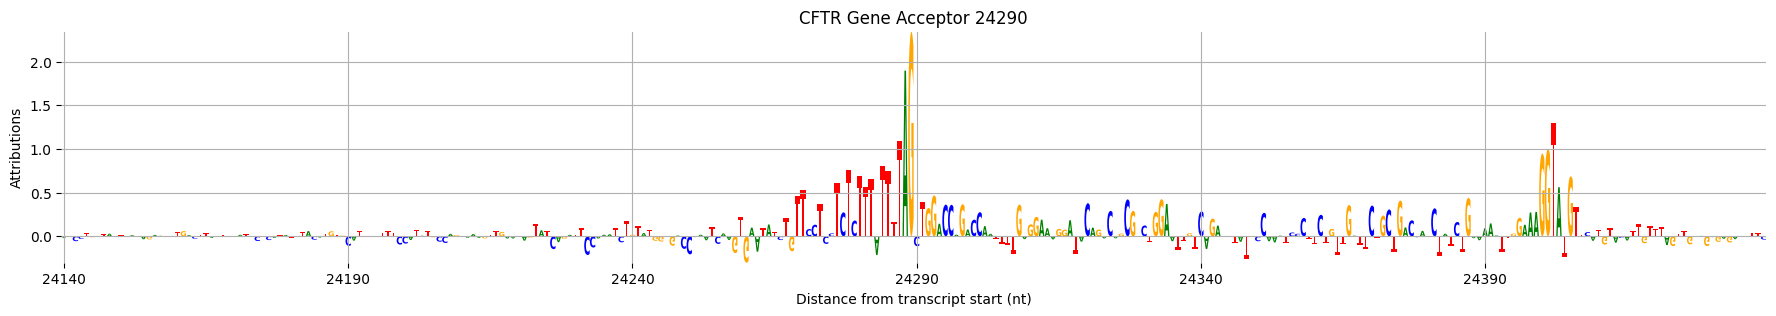

1 4400
tensor(5.5824, grad_fn=<SelectBackward0>)


tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.7220e-06,
        3.8147e-06, 3.8147e-06, 1.9073e-06, 3.8147e-06, 3.8147e-06, 0.0000e+00,
        1.9073e-06, 3.8147e-06, 3.8147e-06, 1.9073e-06, 3.8147e-06, 1.9073e-06,
        7.6294e-06, 5.7220e-06], grad_fn=<AbsBackward0>)


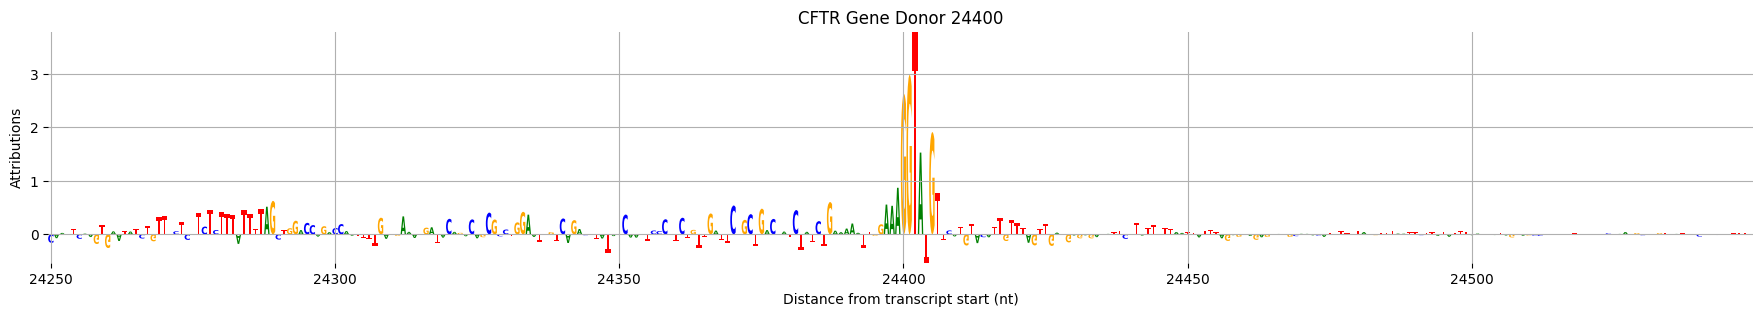

 13%|█▎        | 5/38 [01:36<10:34, 19.23s/it]

Transcript spans: 0 to 14999
0 4071
tensor(4.0124, grad_fn=<SelectBackward0>)


tensor([3.8147e-06, 3.8147e-06, 9.5367e-06, 7.6294e-06, 3.8147e-06, 9.5367e-06,
        7.6294e-06, 7.6294e-06, 1.9073e-06, 1.9073e-06, 1.9073e-06, 0.0000e+00,
        7.6294e-06, 5.7220e-06, 3.8147e-06, 3.8147e-06, 9.5367e-06, 1.1444e-05,
        5.7220e-06, 3.8147e-06], grad_fn=<AbsBackward0>)


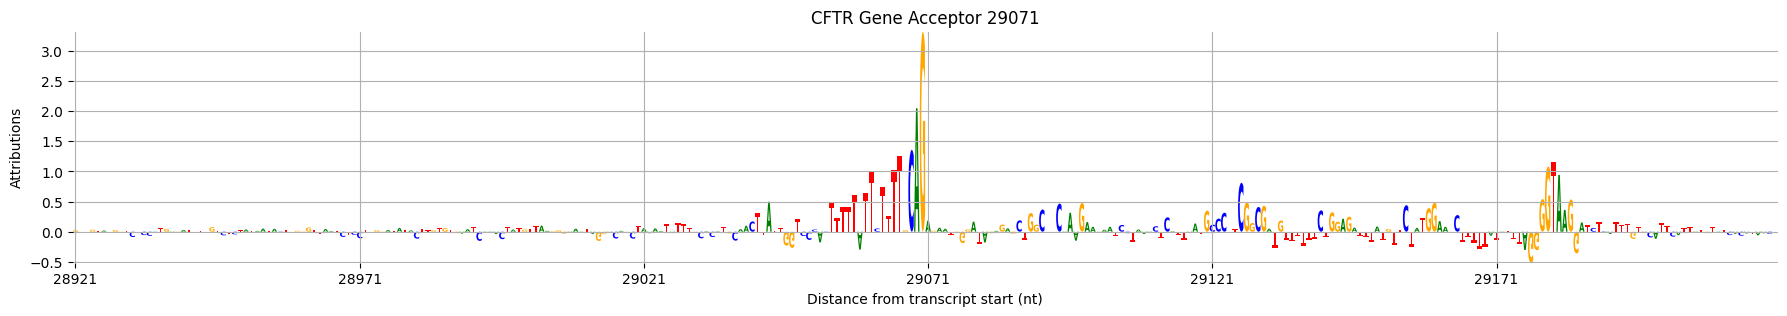

1 4179
tensor(4.8254, grad_fn=<SelectBackward0>)


tensor([0.0000e+00, 3.8147e-06, 9.5367e-06, 1.3351e-05, 7.6294e-06, 1.9073e-06,
        0.0000e+00, 3.8147e-06, 1.9073e-06, 9.5367e-06, 0.0000e+00, 3.8147e-06,
        3.8147e-06, 0.0000e+00, 7.6294e-06, 0.0000e+00, 1.9073e-06, 3.8147e-06,
        7.6294e-06, 7.6294e-06], grad_fn=<AbsBackward0>)


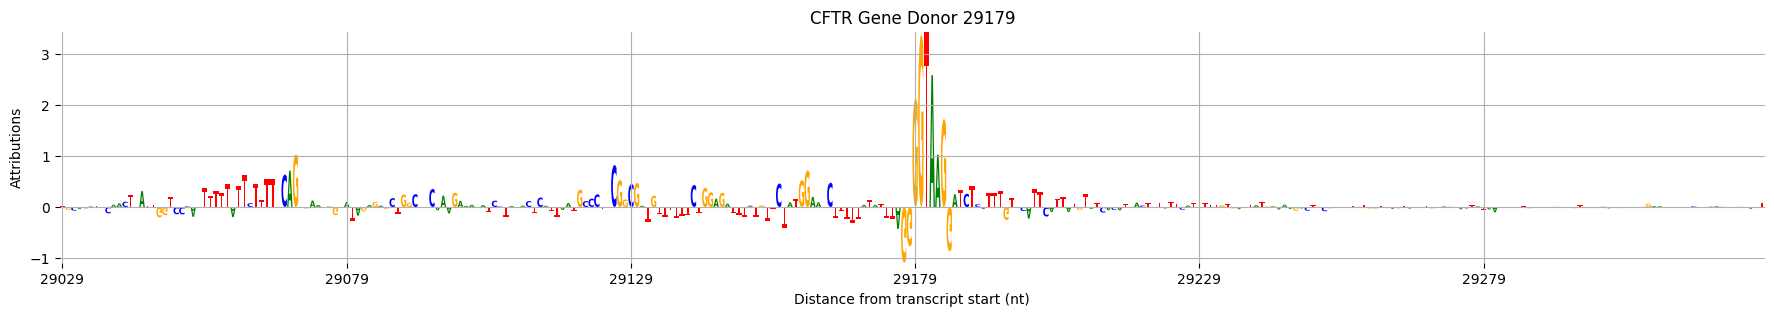

 16%|█▌        | 6/38 [03:11<19:17, 36.18s/it]

Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
Transcript spans: 0 to 14999
0 936
tensor(4.1492, grad_fn=<SelectBackward0>)


tensor([5.7220e-06, 0.0000e+00, 2.8610e-06, 1.9073e-06, 7.6294e-06, 0.0000e+00,
        5.7220e-06, 9.5367e-06, 1.9073e-06, 1.1444e-05, 1.9073e-06, 1.9073e-06,
        0.0000e+00, 3.8147e-06, 3.8147e-06, 0.0000e+00, 0.0000e+00, 7.6294e-06,
        3.8147e-06, 1.9073e-06], grad_fn=<AbsBackward0>)


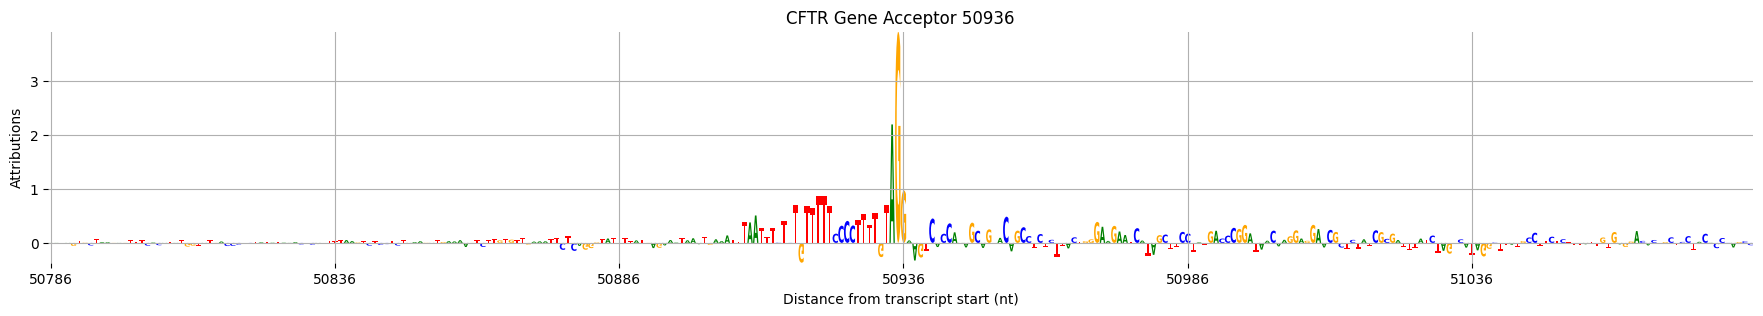

0 4313
tensor(4.7787, grad_fn=<SelectBackward0>)


tensor([5.7220e-06, 5.7220e-06, 7.6294e-06, 3.8147e-06, 5.7220e-06, 5.7220e-06,
        3.8147e-06, 7.6294e-06, 3.8147e-06, 1.1444e-05, 9.5367e-06, 3.8147e-06,
        3.8147e-06, 1.9073e-06, 3.8147e-06, 3.8147e-06, 7.6294e-06, 7.6294e-06,
        7.6294e-06, 5.7220e-06], grad_fn=<AbsBackward0>)


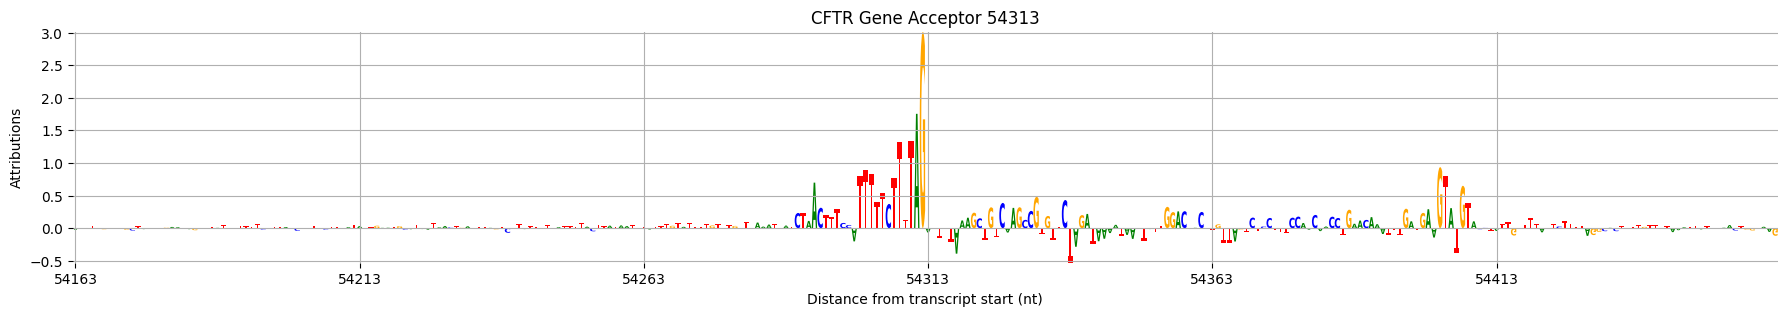

1 1151
tensor(4.4873, grad_fn=<SelectBackward0>)


tensor([1.9073e-06, 3.8147e-06, 5.7220e-06, 5.7220e-06, 5.7220e-06, 3.8147e-06,
        5.7220e-06, 3.8147e-06, 1.9073e-06, 0.0000e+00, 3.8147e-06, 3.8147e-06,
        1.9073e-06, 3.8147e-06, 3.8147e-06, 1.9073e-06, 7.6294e-06, 1.9073e-06,
        1.9073e-06, 7.6294e-06], grad_fn=<AbsBackward0>)


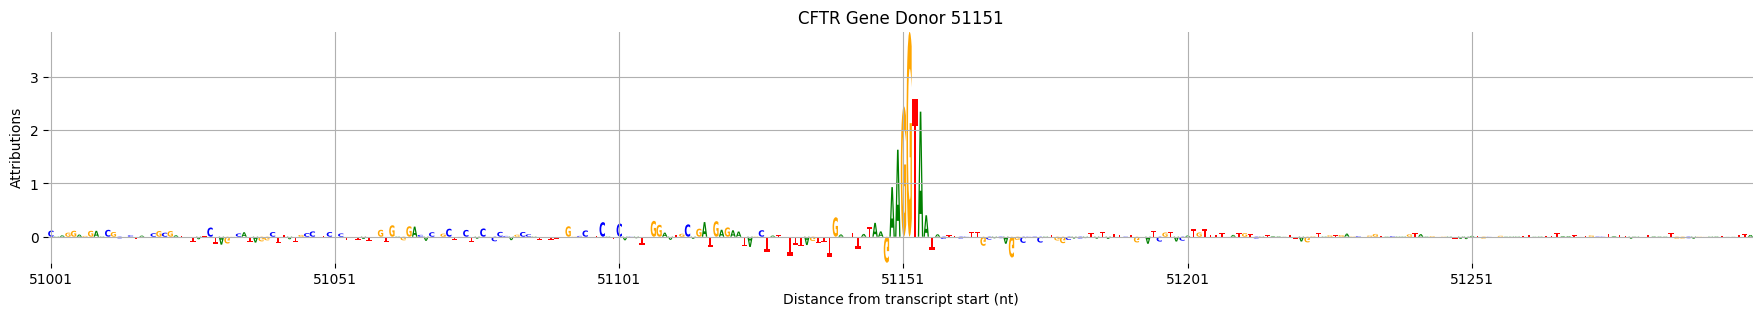

1 4402
tensor(6.0325, grad_fn=<SelectBackward0>)


tensor([1.9073e-06, 1.9073e-06, 0.0000e+00, 1.9073e-06, 1.9073e-06, 1.9073e-06,
        1.9073e-06, 1.9073e-06, 3.8147e-06, 9.5367e-06, 5.7220e-06, 3.8147e-06,
        1.9073e-06, 3.8147e-06, 5.7220e-06, 1.9073e-06, 1.9073e-06, 0.0000e+00,
        1.9073e-06, 7.6294e-06], grad_fn=<AbsBackward0>)


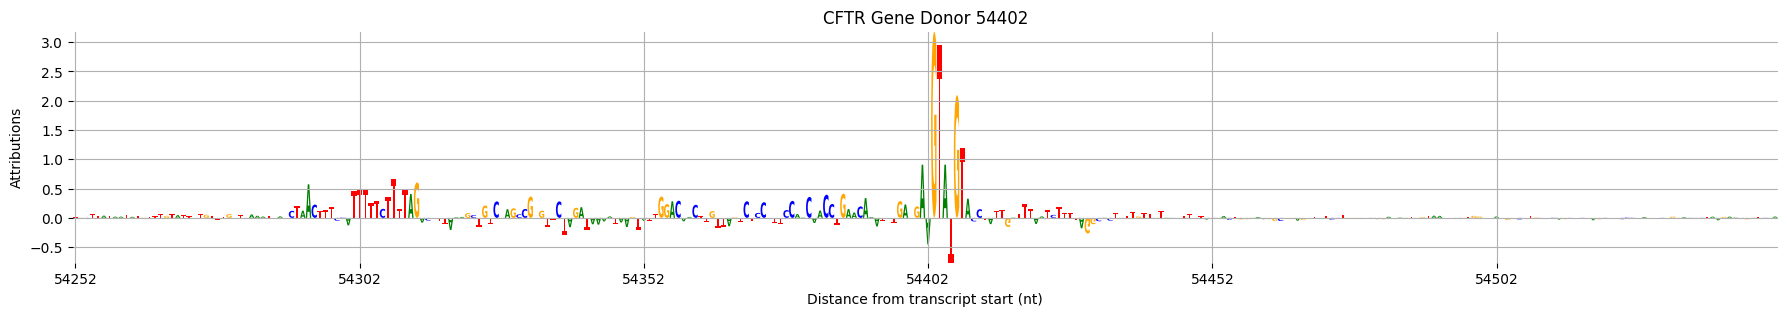

 29%|██▉       | 11/38 [06:24<16:54, 37.59s/it]

Transcript spans: 0 to 14999
0 285
tensor(4.9859, grad_fn=<SelectBackward0>)


tensor([1.9073e-06, 1.9073e-06, 5.7220e-06, 0.0000e+00, 3.8147e-06, 3.8147e-06,
        1.9073e-06, 5.7220e-06, 1.9073e-06, 1.9073e-06, 1.9073e-06, 3.8147e-06,
        1.9073e-06, 1.9073e-06, 0.0000e+00, 1.9073e-06, 1.9073e-06, 9.5367e-06,
        1.9073e-06, 3.8147e-06], grad_fn=<AbsBackward0>)


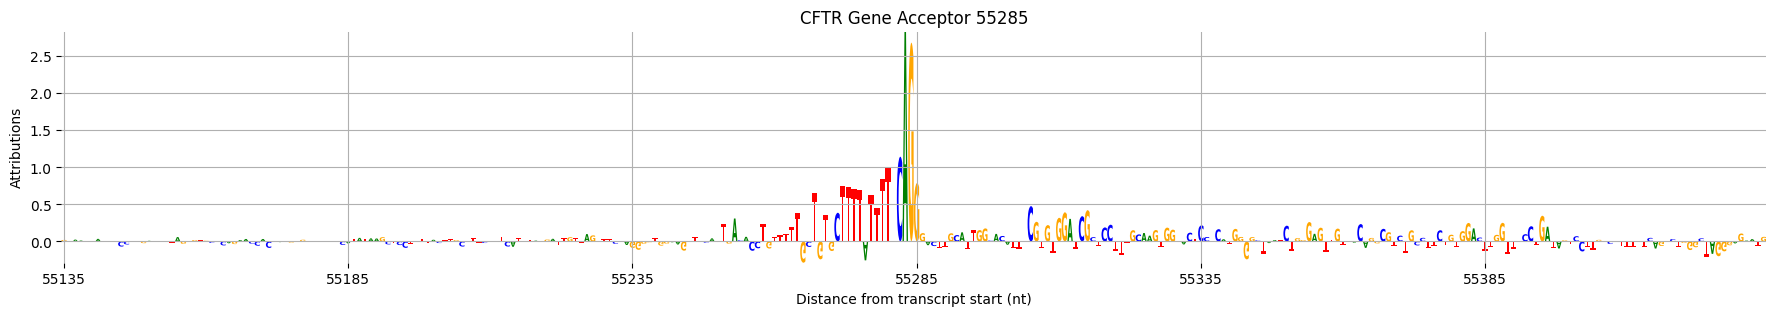

0 1585
tensor(5.4941, grad_fn=<SelectBackward0>)


tensor([3.8147e-06, 1.9073e-06, 0.0000e+00, 7.6294e-06, 1.9073e-06, 5.7220e-06,
        1.9073e-06, 1.9073e-06, 1.9073e-06, 3.8147e-06, 1.9073e-06, 1.9073e-06,
        5.7220e-06, 1.9073e-06, 3.8147e-06, 5.7220e-06, 3.8147e-06, 7.6294e-06,
        0.0000e+00, 3.8147e-06], grad_fn=<AbsBackward0>)


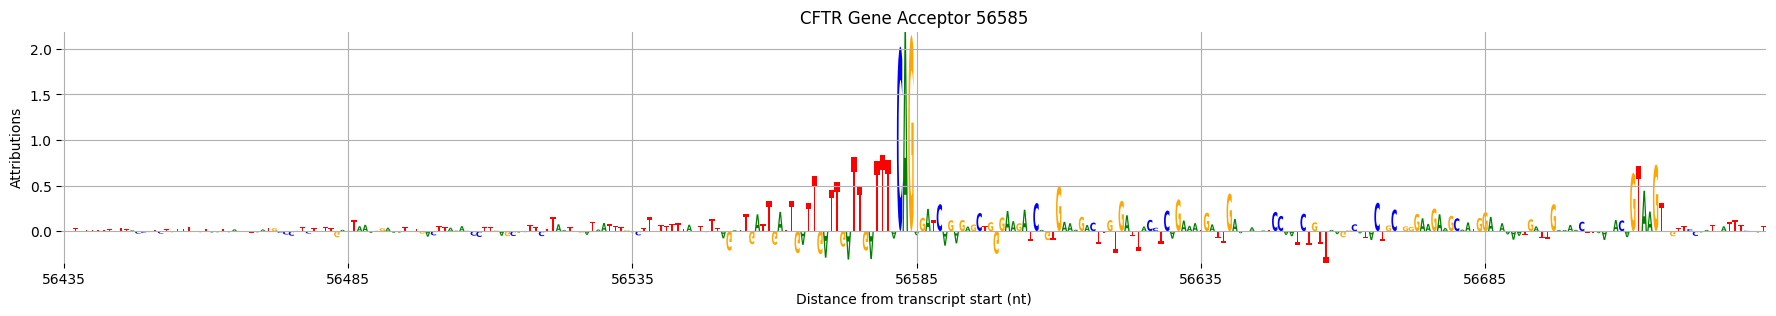

1 448
tensor(7.3132, grad_fn=<SelectBackward0>)


tensor([0.0000e+00, 5.7220e-06, 5.7220e-06, 0.0000e+00, 1.9073e-06, 3.8147e-06,
        5.7220e-06, 3.8147e-06, 1.1444e-05, 0.0000e+00, 7.6294e-06, 5.7220e-06,
        1.1444e-05, 0.0000e+00, 1.9073e-06, 0.0000e+00, 3.8147e-06, 3.8147e-06,
        7.6294e-06, 1.1444e-05], grad_fn=<AbsBackward0>)


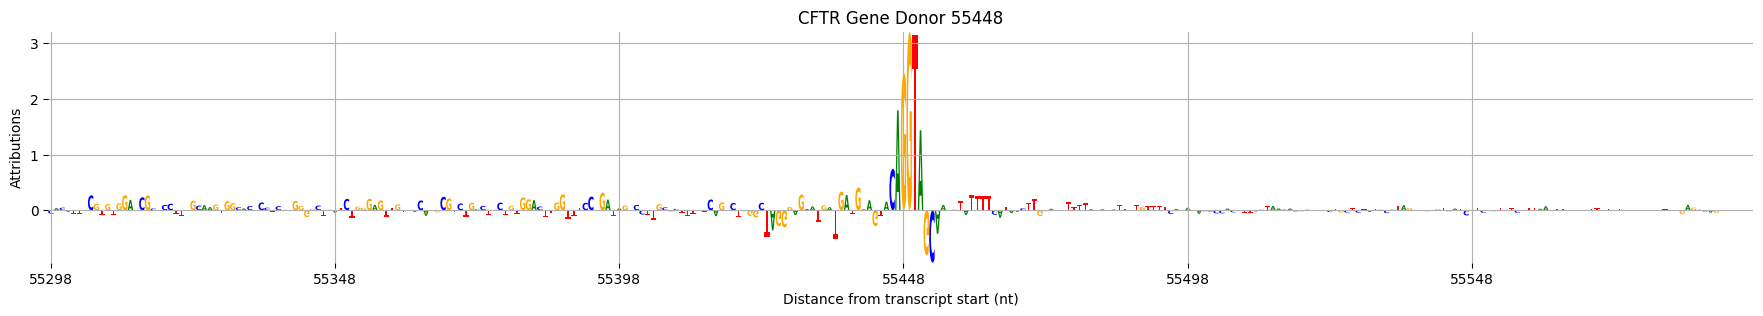

1 1710
tensor(5.8362, grad_fn=<SelectBackward0>)


tensor([1.9073e-06, 1.9073e-06, 3.8147e-06, 0.0000e+00, 0.0000e+00, 3.8147e-06,
        3.8147e-06, 7.6294e-06, 1.9073e-06, 3.8147e-06, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.9073e-06, 3.8147e-06, 3.8147e-06, 1.9073e-06, 0.0000e+00,
        1.9073e-06, 5.7220e-06], grad_fn=<AbsBackward0>)


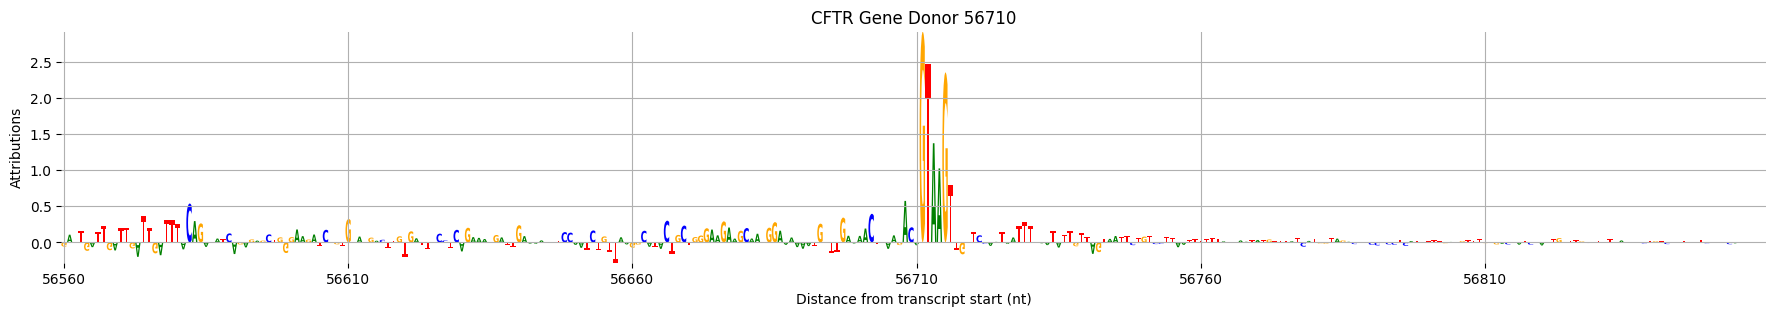

 32%|███▏      | 12/38 [09:35<26:13, 60.51s/it]

Transcript spans: 0 to 14999
0 137
tensor(3.1988, grad_fn=<SelectBackward0>)




 32%|███▏      | 12/38 [09:52<21:24, 49.40s/it]


KeyboardInterrupt: 

In [7]:
test_dataset = spliceDataset(getDataPointListFull(specific_anno,transcriptToLabel_test,SL,CL_max,shift=SL))
test_dataset.seqData = seqData
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
for j,(batch_features ,target) in enumerate(tqdm(test_loader)):
    if j ==0: # Skipping the first iteration as this includes zero padding
        continue
    batch_features = batch_features.type(torch.FloatTensor).to(device)
    target = target.to(device)
    signal = batch_features[0].sum(dim=0)  # shape: [45000]
    nonzero_positions = torch.nonzero(signal > 0).squeeze()
    print("Transcript spans:", nonzero_positions.min().item(), "to", nonzero_positions.max().item())
    deepshap_seq_plot(models,batch_features,target[0,:,:].cpu().numpy(),5000,j*5000)

### Next steps - Acquiring attribution lists for acceptor and donors

Some next steps include running DeepSHAP on lists of acceptors/donors, ideally the ones the model predicts with very high accuracy. I started to try and generate lists of the best performing donors/acceptors across the entire test set. However, the provided SpliceAI_10k model weights from the repository were accidentally trained on the train AND test set, so the saved results I acquired initially when reproducing the papers results reflect this. So it may be worth testing SpliceAI_10k on the entire test set again, but with the correct model weights later added by the authors (spliceai_encoder_10k_191022). From here one could identify the best model predictions across both donors/acceptors and then run DeepSHAP on these sequences.

In [ ]:
annotation, transcriptToLabel, seqData = getData(data_dir, setType)

In [ ]:
spliceai = pd.read_csv('../Data/spliceai_10k_test_ensembl_predictions_300625.csv.gz')
spliceai

In [ ]:
acceptor_hits = spliceai[spliceai["Y_true_acceptor"] == 1]              # rows where true acceptor == 1
acceptor_sorted = acceptor_hits.sort_values(
    by="Y_pred_acceptor", ascending=False
)

# For donors
donor_hits = spliceai[spliceai["Y_true_donor"] == 1]                    # rows where true donor == 1
donor_sorted = donor_hits.sort_values(
    by="Y_pred_donor", ascending=False
)

In [ ]:
print(donor_sorted['Y_pred_donor'].tolist()[:1000])
print(acceptor_sorted)